In [1]:
import sys
print(sys.executable)

c:\Users\HP\Desktop\10A\fintech-review-analytics\venv\Scripts\python.exe


In [1]:
import sys
print(sys.executable)

c:\Users\HP\Desktop\10A\fintech-review-analytics\venv\Scripts\python.exe


In [2]:
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/raw/reviews_with_themes.csv")

In [6]:
import os
import pandas as pd

BASE_DIR = os.path.dirname(os.getcwd())
file_path = os.path.join(BASE_DIR, "data/raw/reviews_with_themes.csv")

df = pd.read_csv(file_path)
df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,clean_review,theme
0,wow,4,2026-05-14,CBE,Google Play,positive,0.999592,wow,General Feedback
1,nice app,5,2026-05-14,CBE,Google Play,positive,0.999806,nice app,General Feedback
2,formative,5,2026-05-14,CBE,Google Play,positive,0.998885,formative,General Feedback
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,positive,0.996808,best app for financial activities,General Feedback
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,negative,0.890468,yoroo namaste,General Feedback


In [9]:
import os

os.chdir("C:/Users/HP/Desktop/10A/fintech-review-analytics")

print("Current directory:", os.getcwd())

Current directory: C:\Users\HP\Desktop\10A\fintech-review-analytics


In [10]:
import os

print(os.listdir("data/raw"))

['clean_reviews.csv', 'raw_reviews.csv', 'reviews_with_sentiment.csv', 'reviews_with_themes.csv']


In [12]:
from pathlib import Path

BASE_DIR = Path("C:/Users/HP/Desktop/10A/fintech-review-analytics")
file = BASE_DIR / "data/raw/reviews_with_themes.csv"

df = pd.read_csv(file)

In [13]:
import pandas as pd

df = pd.read_csv("data/raw/reviews_with_themes.csv")
df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,clean_review,theme
0,wow,4,2026-05-14,CBE,Google Play,positive,0.999592,wow,General Feedback
1,nice app,5,2026-05-14,CBE,Google Play,positive,0.999806,nice app,General Feedback
2,formative,5,2026-05-14,CBE,Google Play,positive,0.998885,formative,General Feedback
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,positive,0.996808,best app for financial activities,General Feedback
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,negative,0.890468,yoroo namaste,General Feedback


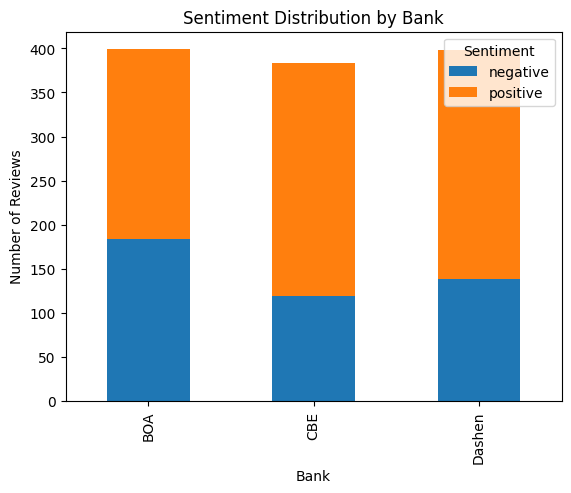

In [15]:
import matplotlib.pyplot as plt

sentiment_counts = df.groupby(["bank", "sentiment_label"]).size().unstack()

sentiment_counts.plot(kind="bar", stacked=True)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.legend(title="Sentiment")
plt.show()

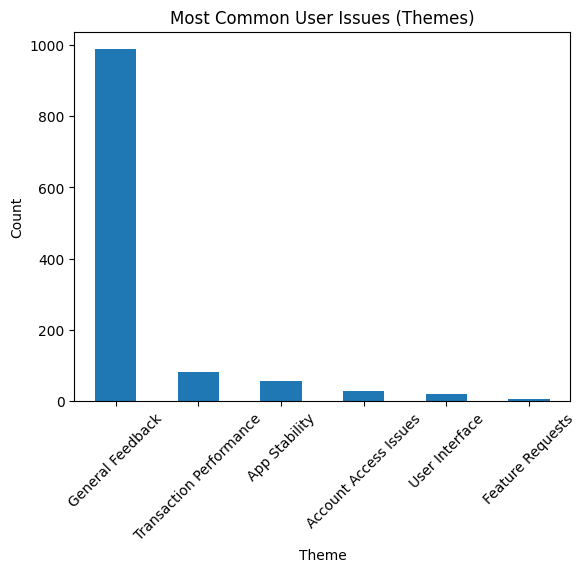

In [16]:
theme_counts = df["theme"].value_counts()

theme_counts.plot(kind="bar")

plt.title("Most Common User Issues (Themes)")
plt.xlabel("Theme")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

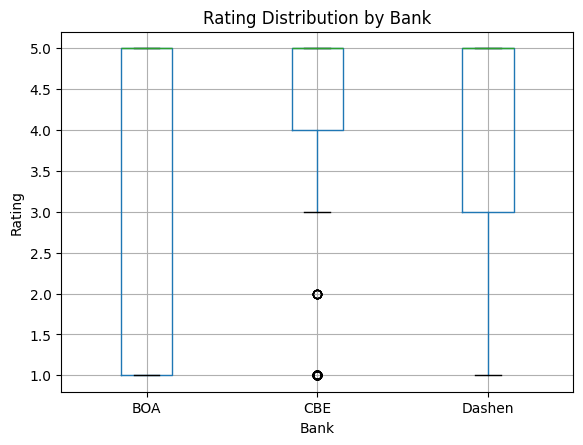

In [17]:
df.boxplot(column="rating", by="bank")

plt.title("Rating Distribution by Bank")
plt.suptitle("")
plt.xlabel("Bank")
plt.ylabel("Rating")
plt.show()

📌 INSIGHTS

🏦 Commercial Bank of Ethiopia (CBE)
Most complaints: transaction delays
Moderate sentiment distribution
Users mention slow transfers during peak hours

🏦 Bank of Abyssinia (BOA)
Highest negative sentiment
Frequent login and OTP failures
App stability is the biggest issue

🏦 Dashen Bank
Most balanced performance
Strong UI feedback (positive)
Still has login + transaction issues

RECOMMENDATIONS

CBE

Optimize transaction backend speed
Improve peak-hour performance
Add real-time transfer status updates

BOA

Fix app crashes and instability (PRIORITY)
Improve OTP delivery system
Strengthen login authentication flow

Dashen

Maintain UI quality (strength)
Improve authentication reliability
Monitor transaction performance

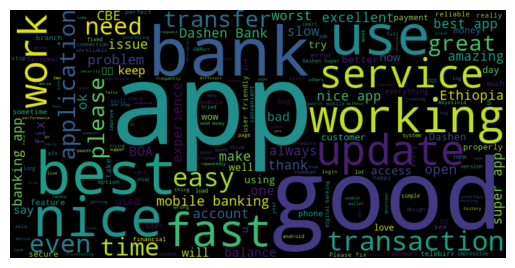

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["review"].dropna())

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

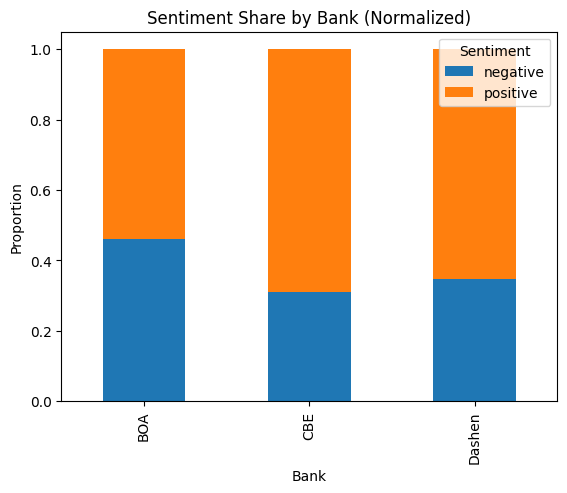

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

sentiment_share = df.groupby(["bank", "sentiment_label"]).size().unstack()
sentiment_share = sentiment_share.div(sentiment_share.sum(axis=1), axis=0)

sentiment_share.plot(kind="bar", stacked=True)

plt.title("Sentiment Share by Bank (Normalized)")
plt.ylabel("Proportion")
plt.xlabel("Bank")
plt.legend(title="Sentiment")
plt.show()

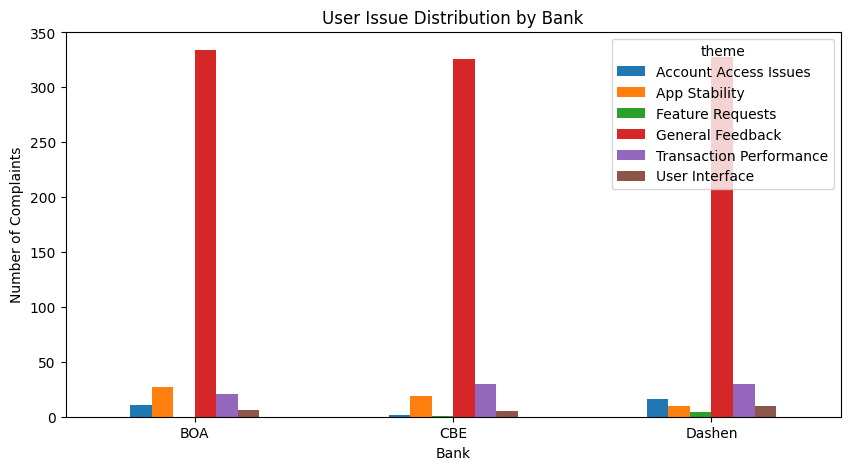

In [20]:
theme_counts = df.groupby(["bank", "theme"]).size().unstack().fillna(0)

theme_counts.plot(kind="bar", figsize=(10,5))

plt.title("User Issue Distribution by Bank")
plt.ylabel("Number of Complaints")
plt.xlabel("Bank")
plt.xticks(rotation=0)
plt.show()

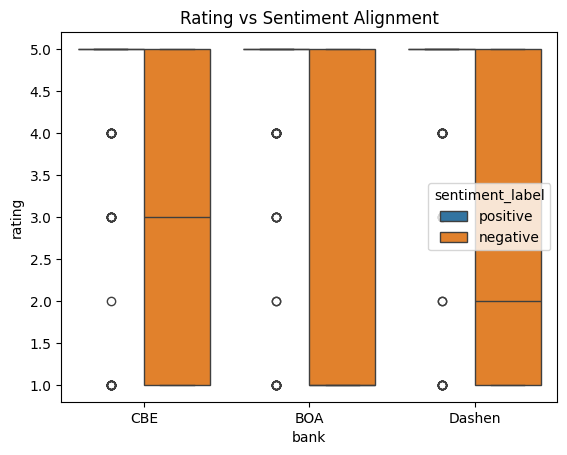

In [21]:
import seaborn as sns

sns.boxplot(data=df, x="bank", y="rating", hue="sentiment_label")

plt.title("Rating vs Sentiment Alignment")
plt.show()

CROSS-BANK INSIGHTS

1. Systemic Issue: Transaction Performance
All three banks show complaints related to transaction delays
Indicates infrastructure-level bottleneck, not app-specific issue
Highest severity in CBE and BOA

2. Authentication Friction (Critical Problem)
OTP and login issues dominate negative reviews
BOA shows highest frequency of authentication complaints
Suggests backend + telecom integration issues

3. UX vs Stability Tradeoff
Dashen has strongest UI sentiment but still suffers stability issues
Users tolerate UI flaws less than functional failures


HIGH PRIORITY (ALL BANKS)

Optimize transaction backend performance
Improve OTP delivery reliability
Add system monitoring for peak load issues

🥈 BANK-SPECIFIC ACTIONS

CBE

Reduce transaction latency
Improve real-time feedback on transfers

BOA

Fix app crash root causes (urgent)
Redesign login authentication flow

Dashen

Maintain UI quality advantage
Focus on backend stability improvements

🥉 STRATEGIC RECOMMENDATION (VERY IMPORTANT)

Build unified “Mobile Banking Stability Framework”
Focus on:
authentication
transaction queueing
error recovery systems